# SOCIAL NETWORK ANALYSIS: CORSO INTRODUTTIVO

### TC CSArs Calanna

<b>AVVERTENZA</b>: la presente esercitazionè si pone l'obiettivo di introdurre i frequentatori ai rudimenti della <em>Social Network Analysis</em> e le sue possibili applicazioni nel campo della selezione del personale (con particolare riferimento alla prove di gruppo) o negli interventi di miglioramento organizzativo. In nessun modo, tale esercitazione può considerarsi esaustiva della materia. Per approfondire alcuni degli argomenti esposti, consiglio di leggere la seguente pubblicazione (anche se un po' datata): Wasserman, S., & Faust, K. (1994). Social network analysis: Methods and applications.

In [4]:
# importa librerie
import random
import numpy as np
import pandas as pd
import networkx as nx
from itertools import permutations, combinations
import networkx.algorithms.connectivity as nxconn
from networkx.algorithms import community as nxcomm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# personlizza pandas
pd.set_option('display.max_columns', None)

In [5]:
# costanti
FIG_SIZE = (10,8)
NODE_SIZE=450
SEED = 42
K_VALUE = .2

BASE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}

NODE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
}

## 1.1 DEFINIZIONE DI SOCIAL NETWORK ANALYSIS

L'analisi delle reti sociali (SNA) indaga le strutture sociali attraverso la teoria dei grafi. La SNA caratterizza i gruppi sociali in termini di nodi (persone) e di collegamenti tra nodi (relazioni, interazioni). Quanto segue è un'introduzione minima ai concetti della SNA descrittiva e, in particolare, alle misure quantitative che saranno usate per analizzare le "interviste di gruppo". 

## 1.2 ELEMENTI DI BASE

Una rete è un sistema di elementi (NODI) e delle relazioni (COLLEGAMENTI) intercorrenti

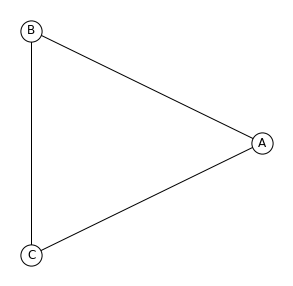

In [17]:
# ESEMPIO DI UNDIRECTED NETWORK (NETWORK NON ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABCA"
nodes = [(x, alpha[idx+1]) for idx, x in enumerate(alpha[:-1])]

Gu = nx.Graph()
Gu.add_edges_from(nodes)
pos = nx.circular_layout(Gu)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax);

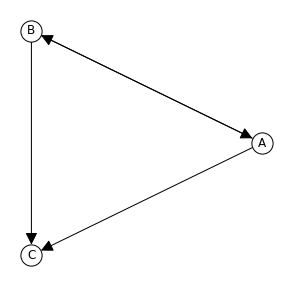

In [11]:
# ESEMPIO DI DIRECTED NETWORK (NETWORK ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABC"
nodes = list(permutations(alpha,2))

Gd = nx.DiGraph()
Gd.add_edges_from(nodes[:-2])
pos = nx.circular_layout(Gd)
options = dict(**BASE_OPTIONS)
options.update({ "arrowsize": 25 })
nx.draw_networkx(Gd, pos, **options, ax=ax);

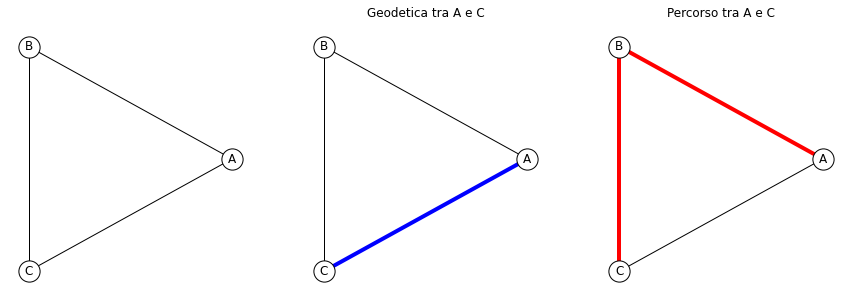

In [15]:
# ESEMPI DI PERCORSO
# (il percorso più breve tra due nodi si chiama geodetica)
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(15,5), nrows=1, ncols=3)

for ax in (ax1, ax2, ax3):
    ax.axis('off')
    
# output network
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax1)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax2)
nx.draw_networkx_edges(Gu, pos, edgelist=[("A","C")], edge_color="b", width=4, ax=ax2)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax3);
nx.draw_networkx_edges(Gu, pos, edgelist=[("A","B"),("B","C")], edge_color="r", width=4, ax=ax3);

ax2.set_title("Geodetica tra A e C");
ax3.set_title("Percorso tra A e C");

## 1.3 LIVELLI DI ANALISI

- Livello <b>MACRO</b>: analisi delle caratterische globali della rete (es., visualizzazione, diametro, densità, centralizzazione, transitività)
- Livello <b>MICRO</b>: analisi dell caratteristiche dei singoli nodi all'interno della rete (es., centralità dei nodi)
- Livello <b>MESO</b>: analisi delle strutture intermedie della rete (es., triadi, clique, k-core)

In [6]:
# carica network da file esterno
np.random.seed(SEED)
Ge = nx.read_edgelist("Ge.edgelist")
spring_pos = nx.spring_layout(Ge, k=K_VALUE, seed=SEED)
circular_pos = nx.circular_layout(Ge)

## 1.4 VISUALIZZAZIONE DEL NETWORK

### 1.4.1 LAYOUT CIRCOLARE

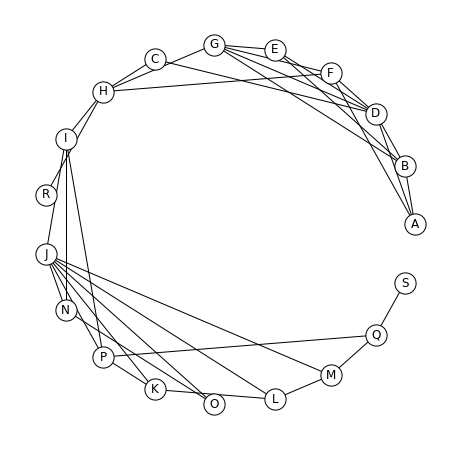

In [18]:
# VISUALIZZAZIONE LAYOUT CIRCOLARE
fig, ax = plt.subplots(figsize=(8,8))
ax.axis('off')

# output network
nx.draw_networkx(Ge, circular_pos, **BASE_OPTIONS, ax=ax)

### 1.4.2 LAYOUT FORCE-DIRECTED

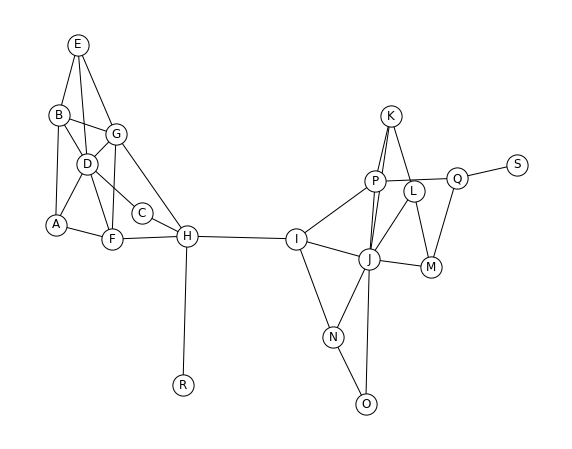

In [19]:
# VISUALIZZAZIONE FORCE-DIRECTED (CAMPO DI FORZA)
def plot_network():
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.axis('off')

    # output network
    nx.draw_networkx(Ge, spring_pos,**BASE_OPTIONS, ax=ax)
    return fig, ax

plot_network();

### 1.4.3 LAYOUT FORCE-DIRECTED

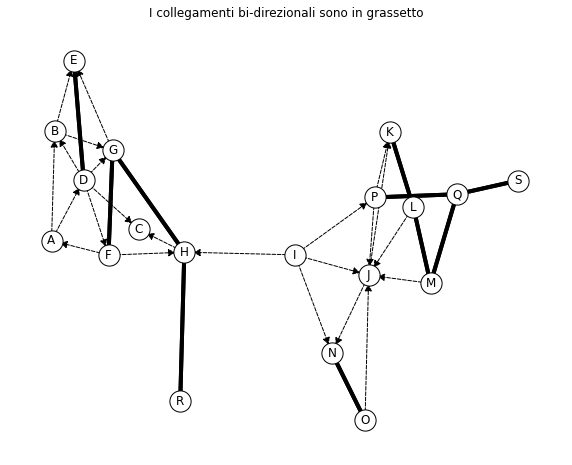

In [20]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

L = Ge.to_directed()
for idx in [30, 31, 25, 20, 24, 33, 38, 10,  7, 35, 36, 39,  3, 42,  8, 34,  4,
       27, 16, 11, 23, 37, 15, 32, 13, 29, 17,  2, 14, 26]:
    (s,t) = list(L.edges)[idx]
    if (s,t) in L.edges and (t,s) in L.edges : L.remove_edge(s,t)
reciprical_edges = [ (s,t) for (s,t) in L.edges if (t,s) in L.edges ]
non_reciprocal_edges = [ e for e in L.edges if e not in reciprical_edges]
loc = nx.spring_layout(L, k=.8, seed=SEED)
nx.draw_networkx_nodes(L,spring_pos, **NODE_OPTIONS, ax=ax);
nx.draw_networkx_edges(L,spring_pos, edgelist = non_reciprocal_edges, style="--", arrowsize=15);
nx.draw_networkx_edges(L,spring_pos, edgelist = reciprical_edges, width=4, arrowstyle="-");
nx.draw_networkx_labels(L,spring_pos)
ax.set_title("I collegamenti bi-direzionali sono in grassetto");

## 1.5 Livello MACRO

### 1.5.1 Diameter
The diameter of a connected graph is the maximum length of a shortest path. That is, it is the maximum of the distances between pairs of vertices in the graph. If the graph has weights on its edges, then its weighted diameter measures path length by the sum of the edge weights along a path, while the unweighted diameter measures path length by the number of edges. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [14]:
# DIAMETRO -- GEODETICA PIU' LUNGA
f"diametro del network: {nx.diameter(Ge)}"

'diametro del network: 6'

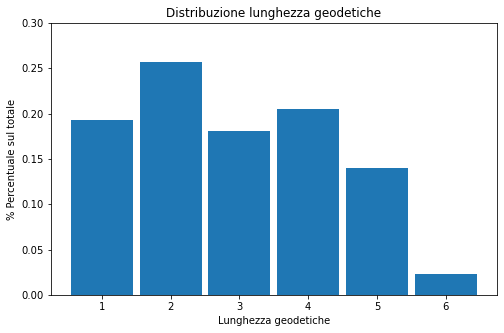

In [16]:
# VISUALIZZA DISTRIBUZIONE LUNGHEZZA DELLE GEODETICHE
fig, ax = plt.subplots(figsize=(8,5))

# dict lunghezza geodetiche
dict_shortest = dict(nx.shortest_path_length(Ge))

# appittisci dict geodetiche
flattened_shortest = sum(map(lambda x: list(x.values()), dict_shortest.values()), [])
flattened_shortest = [x for x in flattened_shortest if x > 0]

# geodetica più lunga
high = max(flattened_shortest)

# output grafico
bins = [0.5 + i for i in range(high + 1)]
g = ax.hist(flattened_shortest, bins=bins, rwidth=.9, density=True)
ax.set_title("Distribuzione lunghezza geodetiche")
ax.set_xlabel("Lunghezza geodetiche")
ax.set_ylabel("% Percentuale sul totale")
ax.set_ylim(0,.3);

['A', 'F', 'H', 'I', 'P', 'Q', 'S']

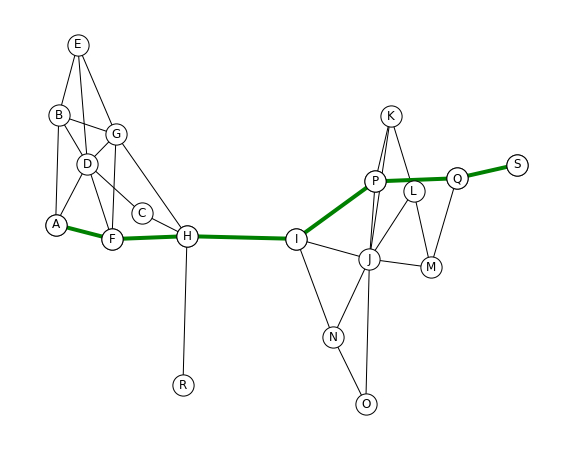

In [28]:
# GEODETICA TRA A ED S
fig, ax = plot_network()

possible_sps = list(nx.all_shortest_paths(Ge, "A", "S"))
first_sp = possible_sps[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx,x in enumerate(first_sp[:-1]) ]

display(list(nx.all_shortest_paths(Ge,"A","S"))[0])
nx.draw_networkx_nodes(Ge, pos=spring_pos, nodelist=first_sp, **NODE_OPTIONS, ax=ax)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=first_sp_edges, edge_color="g", width=4, ax=ax);

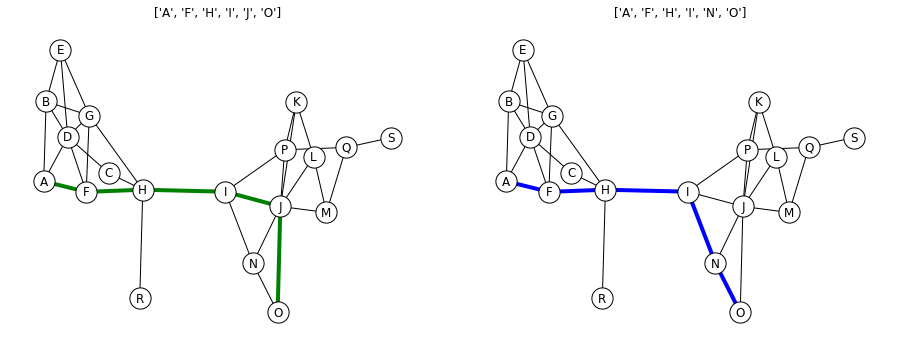

In [27]:
# GEODETICHE TRA A ED O

fig, (ax1, ax2) = plt.subplots(figsize=(13,5), nrows=1, ncols=2)
fig.tight_layout()

for ax in (ax1, ax2):
    ax.axis('off')

# calcola tutte le possibili geodetiche
possible_sps = list(nx.all_shortest_paths(Ge, "A", "O"))

# scegli prima geodetica
first_sp = possible_sps[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx, x in enumerate(first_sp[:-1]) ]
# scegli seconda geodetica
second_sp = possible_sps[1]
second_sp_edges = [ (x, second_sp[idx+1]) for idx, x in enumerate(second_sp[:-1]) ]

# output grafico
nx.draw_networkx(Ge, pos=spring_pos, **NODE_OPTIONS, ax=ax1)
nx.draw_networkx(Ge, pos=spring_pos, **NODE_OPTIONS, ax=ax2)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=first_sp_edges, edge_color="g", width=4, ax=ax1)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=second_sp_edges, edge_color="b", width=4, ax=ax2);
ax1.set_title(possible_sps[0]);
ax2.set_title(possible_sps[1]);

### 1.5.2 DENSITY
In a graph of n nodes, the density is the ratio of the number of edges of the graph to the number of edges in a complete graph on n nodes.

In [21]:
density = nx.density(Ge)
f"density: {np.round(density,2)}"

'density: 0.19'

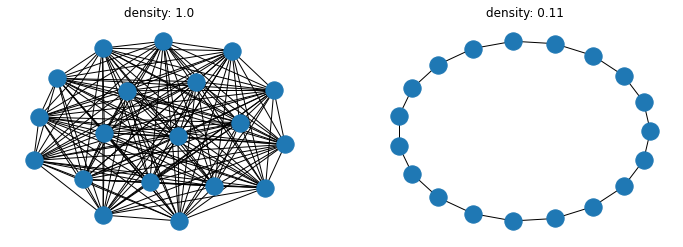

In [29]:
# ESEMPI DI DENSITA'
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.complete_graph(19)
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"density: {nx.density(S)}")

C = nx.Graph()
nodes = range(19)
C.add_nodes_from(nodes)
C.add_edges_from(
    sum([[(x,nodes[idx+1]) for idx,x in enumerate(nodes[:-1])], [(nodes[0], nodes[-1])]], [])
)
loc = nx.circular_layout(C)
nx.draw(C,loc, ax=ax2)
ax2.set_title(f"density: {np.round(nx.density(C),2)}");

### 1.5.3 CENTRALIZATION

The Centralization coefficient expresses how much a network is organized around a focal point (or some focal points).

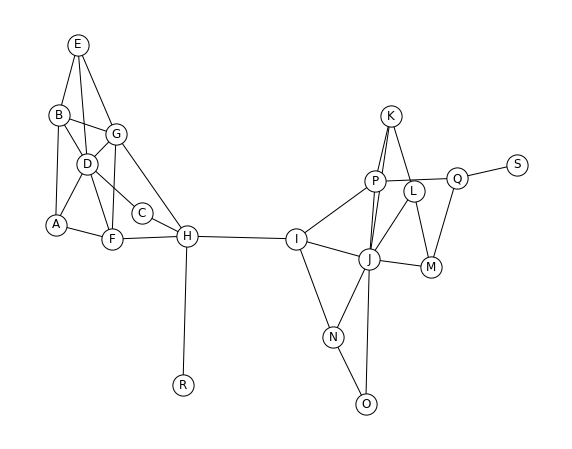

In [30]:
fig, ax = plot_network()

In [33]:
def get_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"centralizzazione: {np.round(get_centralization(Ge),2)}"

'centralizzazione: 0.22'

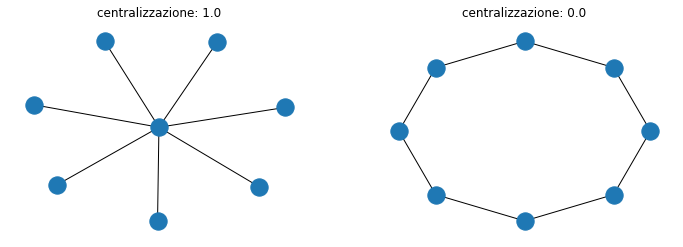

In [40]:
# ESEMPI DI CENTRALIZATION
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.Graph()
S.add_nodes_from(range(8))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"centralizzazione: {get_centralization(S)}")

C = C = nx.watts_strogatz_graph(8, 2, 0)
loc = nx.circular_layout(C)
nx.draw(C,loc, ax=ax2)
ax2.set_title(f"centralizzazione: {get_centralization(C)}");

### 1.5.4 TRANSITIVITY

Transitivity indcates the propensity of a network to form closed triads and - more generaly - clusters of nodes highly connected.

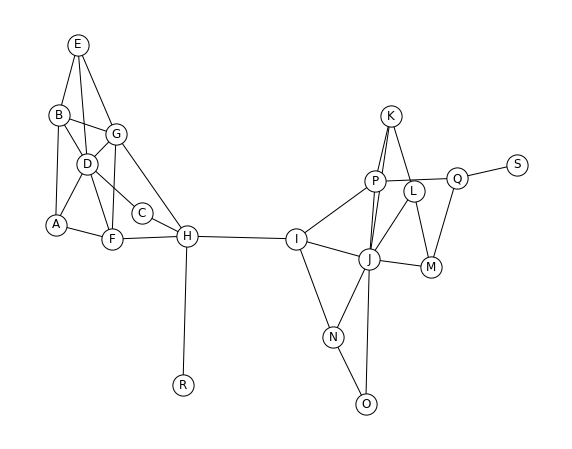

In [34]:
fig, ax = plot_network()

In [36]:
f"transitivity: {np.round(nx.transitivity(Ge),2)}"

'transitivity: 0.41'

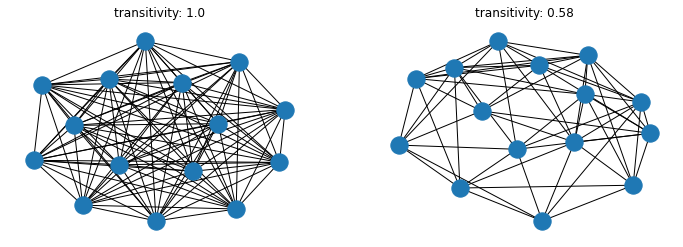

In [42]:
# ESEMPI DI TRANSITIVITY
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.complete_graph(15)
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"transitivity: {np.round(nx.transitivity(S),3)}")

C = nx.watts_strogatz_graph(15, 8, .3, seed=42)
loc = nx.spring_layout(C)
nx.draw(C,loc,ax=ax2)
ax2.set_title(f"transitivity: {np.round(nx.transitivity(C),3)}");

## 1.6 Livello MICRO

### 1.6.1 Degree centrality and Eigenvector Centrality (undirected)

The number of links incident upon a node (i.e., the number of ties that a node has).

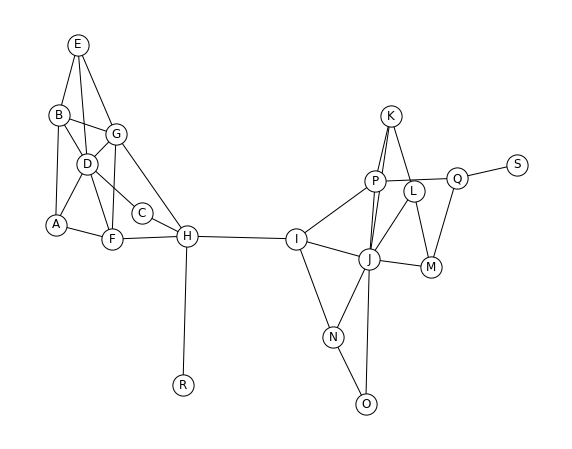

In [101]:
fig, ax = plot_network()
d = list(nx.degree(Ge))
e = [ (k,round(v,2)) for k,v in dict(nx.eigenvector_centrality(Ge, max_iter=1000)).items()]
zip(d,e)
#sorted(dict(nx.degree(Ge)).items(), key=lambda x: x[1], reverse=True)

### 1.6.2 PageRank Centrality

There are three distinct factors that determine the PageRank of a node: (i) the number of links it receives, (ii) the link propensity of the linkers, and (iii) the centrality of the linkers. The first factor is not surprising: the more links a node attracts, the more important it is perceived. Reasonably, the value of the endorsement depreciates proportionally to the number of links given out by the endorsing node: links coming from parsimonious nodes are worthier than those emanated by spendthrift ones. Finally, not all nodes are created equal: links from important vertices are more valuable than those from obscure ones. This method has been coined (and patented) by Sergey Brin and Larry Page (The anatomy of a large-scale hypertextual web search engine. Computer networks and ISDN systems, 1998)

[('A', 0.37967218961493926),
 ('B', 0.12763489478351214),
 ('D', 0.12160720787067021),
 ('I', 0.0874534674178424),
 ('C', 0.047272040052172726),
 ('E', 0.047272040052172726),
 ('F', 0.047272040052172726),
 ('G', 0.047272040052172726),
 ('H', 0.047272040052172726),
 ('L', 0.047272040052172726)]

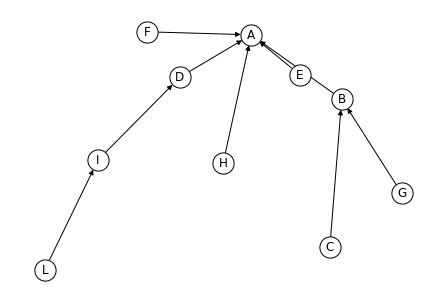

In [92]:
Gp = nx.gnr_graph(10,.2, seed=SEED)
Gp = nx.relabel_nodes(Gp, {k:"ABCDEFGHIL"[k] for k in Gp.nodes() })
nx.draw(Gp, nx.spring_layout(Gp, seed=SEED), **BASE_OPTIONS, with_labels=True)
sorted(nx.pagerank(Gp).items(), key=lambda x: x[1], reverse=True)

## 1.2 Livello MESO

In [7]:
# carica da file esterno
Gi = nx.read_edgelist("Gi.edgelist")
pos= nx.spring_layout(Gi, k=K_VALUE, seed=SEED)

### 1.2.1 Triangolo

A triangle consists of a closed triplet of nodes.

[['A', 'B', 'D'],
 ['A', 'D', 'F'],
 ['B', 'D', 'E'],
 ['B', 'D', 'G'],
 ['B', 'E', 'G'],
 ['D', 'F', 'G'],
 ['D', 'E', 'G'],
 ['F', 'G', 'H']]

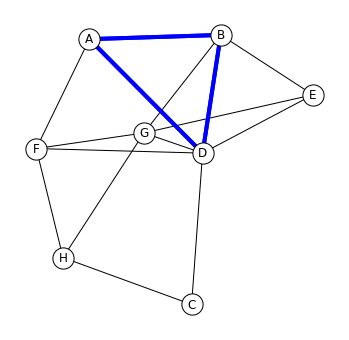

In [8]:
# TUTTI I TRIANGOLI
all_cliques = list(nx.enumerate_all_cliques(Gi))
triangles = [clq for clq in all_cliques if len(clq) == 3]
display(triangles)

fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = list(permutations(triangles[0], 2))
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);

### 1.2.2 CLIQUE

A clique is a subset of vertices of an undirected graph such that every two distinct vertices in the clique are adjacent. That is, a clique of a graph G is an induced subgraph of G that is complete.

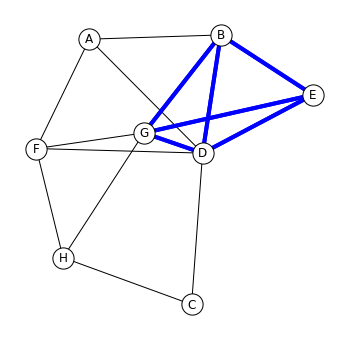

In [9]:
# CLIQUE MASSIMA
max_clique = list(nx.enumerate_all_cliques(Gi))[-1]

fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = list(permutations(max_clique, 2))
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);

### 1.2.3 K-CORE

A k-core of a network is a subgraph in which each node has at least k connections to other nodes in the subgraph.

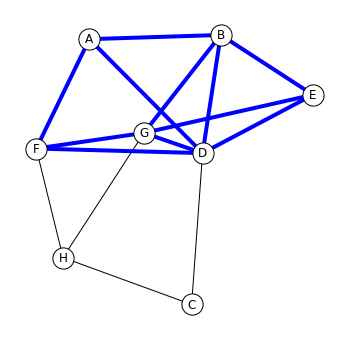

In [10]:
# K-CORE CON K=3
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = nx.algorithms.core.k_core(Gi, 3).edges()
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);